<a href="https://colab.research.google.com/github/7500nidhi/Artificial_Intelligence_Course/blob/main/Assignment11_c12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
# Import Libraries

import numpy as np
import matplotlib.pyplot as plt
import skimage.io
import os
import cv2

from pathlib import Path
from sklearn.utils import Bunch
from skimage.transform import resize

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [3]:
# Unzip the Dataset and create a folder dataset

from zipfile import ZipFile

with ZipFile("images.zip","r") as zip_ref:
    zip_ref.extractall("/content/dataset")

In [4]:
# Check the folder structure

print(os.listdir("/content/dataset"))

['images']


In [5]:
print(os.listdir("/content/dataset/images"))

['sunflower', 'dalmatian', 'dollar_bill', 'soccer_ball', 'pizza']


In [6]:
# Set the Image Folder
image_folder = "/content/dataset/images"

In [7]:
# Create a function

def load_image_files(container_path, dimension=(64,64)):

    image_dir = Path(container_path)

    folders = [folder for folder in image_dir.iterdir() if folder.is_dir()]

    categories = [folder.name for folder in folders]

    descr = "Image Classification Dataset"

    images = []

    flat_data = []

    target = []

    for i, folder in enumerate(folders):

        for file in folder.iterdir():
            img = skimage.io.imread(file)
            img_resized = resize(
                img,
                dimension,
                anti_aliasing=True,
                mode="reflect"
            )
            flat_data.append(img_resized.flatten())
            images.append(img_resized)
            target.append(i)

    flat_data = np.array(flat_data)
    target = np.array(target)
    images = np.array(images)

    return Bunch(
        data=flat_data,
        target=target,
        target_names=categories,
        images=images,
        DESCR=descr
    )

In [8]:
# Load the Dataset

image_dataset = load_image_files(image_folder)

In [9]:
# Check the Dataset

print(image_dataset.data.shape)

print(image_dataset.images.shape)

print(image_dataset.target.shape)

print(image_dataset.target_names)

(309, 12288)
(309, 64, 64, 3)
(309,)
['sunflower', 'dalmatian', 'dollar_bill', 'soccer_ball', 'pizza']


In [11]:
# Split the Dataset

X_train, X_test, y_train, y_test = train_test_split(
    image_dataset.data,
    image_dataset.target,
    test_size=0.2,
    random_state=42,
    stratify=image_dataset.target
)

In [14]:
# Train data with parameter optimization

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=42)

clf = GridSearchCV(rf, param_grid, cv=3)

clf.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100]})

In [15]:
# Predict

y_pred = clf.predict(X_test)

In [16]:
# Classification Report

print("Classification Report\n")

print(classification_report( y_test, y_pred, target_names=image_dataset.target_names))

Classification Report

              precision    recall  f1-score   support

   sunflower       0.70      0.94      0.80        17
   dalmatian       0.79      0.79      0.79        14
 dollar_bill       0.73      0.80      0.76        10
 soccer_ball       0.88      0.64      0.74        11
       pizza       0.67      0.40      0.50        10

    accuracy                           0.74        62
   macro avg       0.75      0.71      0.72        62
weighted avg       0.75      0.74      0.73        62



**Explaination :** Precision: Out of all the images the model predicted as a particular class, how many were actually correct?
Recall: Out of all the actual images of a particular class, how many did the model correctly identify?
F1-score: A balance between precision and recall. A higher value indicates better overall performance.
Support: The number of test images that belong to that class.

 The model performed best for the sunflower class with a recall of 94%, showing that most sunflower images were correctly identified. The dalmatian and dollar_bill classes also achieved good results, with F1-scores of 0.79 and 0.76, respectively. The soccer_ball class had the highest precision (0.88), indicating that most images predicted as soccer balls were correct, although some soccer ball images were missed due to its lower recall (0.64). The pizza class had the lowest performance, with an F1-score of 0.50, making it the most difficult class for the model to classify. Overall, the Random Forest model showed good performance and was able to correctly classify the majority of images in the dataset.



In [17]:
# Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7419354838709677


The Random Forest model achieved an overall accuracy of 74%, which means it correctly classified 74% of the test images.

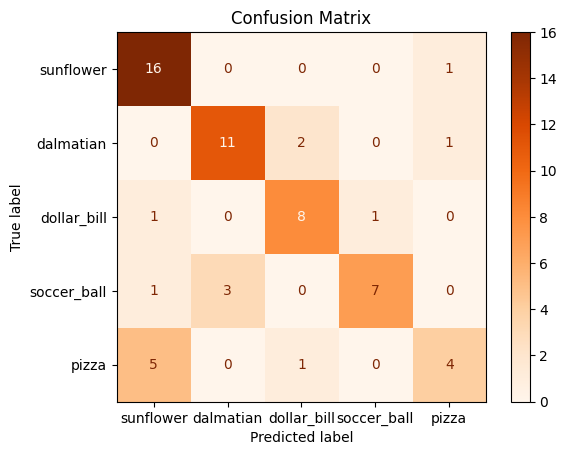

In [20]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=image_dataset.target_names
)

disp.plot(cmap="Oranges")

plt.title("Confusion Matrix")

plt.show()

The confusion matrix shows how well the Random Forest model classified each image category. Most images were correctly classified, as shown by the higher values along the diagonal of the matrix. The model performed best on the sunflower class, correctly identifying 16 out of 17 images. It also classified 11 dalmatian, 8 dollar bill, and 7 soccer ball images correctly. However, the model had more difficulty with the pizza class, correctly classifying only 4 out of 10 images, with 5 pizza images incorrectly predicted as sunflower. Some confusion was also observed between dalmatian and dollar bill images and between soccer ball and dalmatian images. Overall, the confusion matrix indicates that the model performed well for most classes but made more errors when distinguishing pizza and a few visually similar categories.

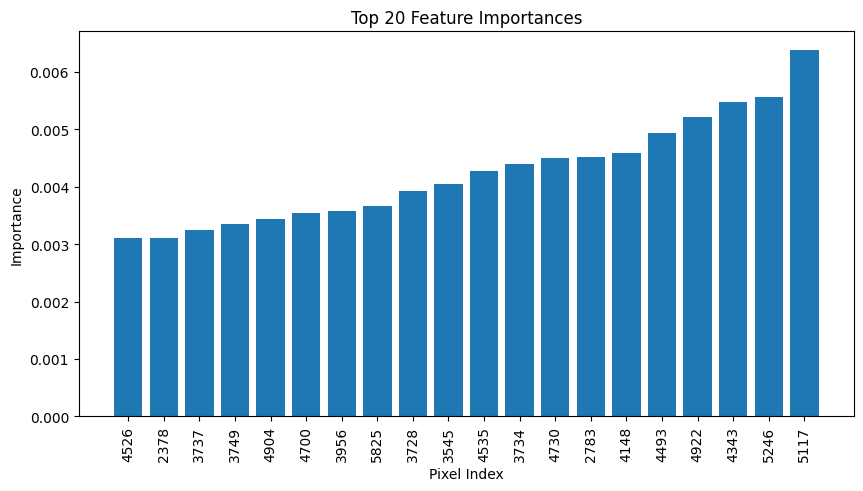

In [21]:
# Feature Importance

importance = clf.best_estimator_.feature_importances_

indices = np.argsort(importance)[-20:]

plt.figure(figsize=(10,5))

plt.bar(range(len(indices)), importance[indices])

plt.xticks(range(len(indices)), indices, rotation=90)

plt.title("Top 20 Feature Importances")

plt.xlabel("Pixel Index")

plt.ylabel("Importance")

plt.show()

The feature importance graph shows the 20 most important pixel features that the Random Forest model used to classify the images. Each bar represents a pixel index, and taller bars indicate pixels that had a greater influence on the model's predictions. The graph shows that some pixel features, such as pixel index 5117, had a higher importance than others, while the remaining important pixels also contributed to distinguishing between the five image classes. Since each image contains thousands of pixels, only the top 20 most important features are displayed. These important pixel values helped the Random Forest model identify patterns in the images and improve its classification performance.

In [22]:
# Prediction on New Images

def predict_image(path):
    img = skimage.io.imread(path)
    img = resize(
        img,
        (64,64),
        anti_aliasing=True,
        mode="reflect"
    )

    img = img.flatten().reshape(1,-1)
    prediction = clf.predict(img)
    print("Predicted Class:",image_dataset.target_names[prediction[0]])

In [23]:
# Choose a test image

print(os.listdir("/content/dataset/images/pizza"))

['image_0052.jpg', 'image_0007.jpg', 'image_0034.jpg', 'image_0010.jpg', 'image_0028.jpg', 'image_0039.jpg', 'image_0022.jpg', 'image_0001.jpg', 'image_0036.jpg', 'image_0024.jpg', 'image_0005.jpg', 'image_0035.jpg', 'image_0004.jpg', 'image_0016.jpg', 'image_0040.jpg', 'image_0002.jpg', 'image_0011.jpg', 'image_0041.jpg', 'image_0037.jpg', 'image_0021.jpg', 'image_0047.jpg', 'image_0031.jpg', 'image_0048.jpg', 'image_0018.jpg', 'image_0032.jpg', 'image_0051.jpg', 'image_0015.jpg', 'image_0049.jpg', 'image_0017.jpg', 'image_0003.jpg', 'image_0045.jpg', 'image_0026.jpg', 'image_0030.jpg', 'image_0023.jpg', 'image_0012.jpg', 'image_0046.jpg', 'image_0009.jpg', 'image_0027.jpg', 'image_0029.jpg', 'image_0042.jpg', 'image_0043.jpg', 'image_0013.jpg', 'image_0006.jpg', 'image_0038.jpg', 'image_0019.jpg', 'image_0050.jpg', 'image_0008.jpg', 'image_0044.jpg', 'image_0014.jpg', 'image_0020.jpg', 'image_0053.jpg', 'image_0025.jpg']


In [24]:
predict_image("/content/dataset/images/pizza/image_0052.jpg")

Predicted Class: pizza


In [25]:
# Display the image

def predict_image(path):
    img = skimage.io.imread(path)
    img = resize(
        img,
        (64,64),
        anti_aliasing=True,
        mode="reflect"
    )
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    img = img.flatten().reshape(1,-1)
    prediction = clf.predict(img)
    print("Predicted Class:", image_dataset.target_names[prediction[0]])

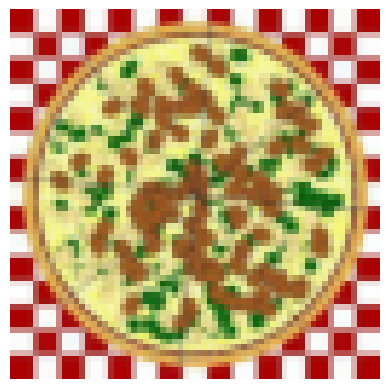

Predicted Class: pizza


In [26]:
predict_image("/content/dataset/images/pizza/image_0052.jpg")

The predict_image() function is used to predict the class of a new image using the trained Random Forest model. The function first reads the input image, resizes it to 64 × 64 pixels, and applies the same preprocessing steps used during training. It then displays the image, converts it into a one-dimensional feature vector by flattening it, and passes it to the trained model for prediction. Finally, the function prints the predicted image category. In this example, a pizza image from the dataset was used as the test image, and the model successfully displayed the image and predicted its corresponding class. This demonstrates that the trained model can classify new images using the same preprocessing and prediction workflow as the training data.

In [27]:
# Bonus: Comparing with SVM

# Define the Parameter Grid

param_grid_svm = [
    {'C': [1, 10, 100, 1000], 'kernel': ['linear']},
    {'C': [1, 10, 100, 1000], 'gamma': [0.001, 0.0001], 'kernel': ['rbf']}
]

In [28]:
# Create the SVM Model
svc = SVC()

# Apply GridSearchCV
svm_clf = GridSearchCV(
    svc,
    param_grid_svm,
    cv=3
)
svm_clf.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=SVC(),
             param_grid=[{'C': [1, 10, 100, 1000], 'kernel': ['linear']},
                         {'C': [1, 10, 100, 1000], 'gamma': [0.001, 0.0001],
                          'kernel': ['rbf']}])

In [29]:
# Make Predictions
svm_pred = svm_clf.predict(X_test)

In [30]:
# Print Accuracy
from sklearn.metrics import accuracy_score

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.8064516129032258


Explaination: The SVM model achieved an accuracy of 80.65%, which means it correctly classified about 81 out of every 100 images in the test dataset. This result shows that the SVM model performed well in identifying the different image categories. Since its accuracy was higher than the Random Forest model (74.19%), the SVM model provided better classification performance for this dataset.

In [31]:
# Classification Report

print("SVM Classification Report\n")
print(classification_report(
    y_test,
    svm_pred,
    target_names=image_dataset.target_names
))

SVM Classification Report

              precision    recall  f1-score   support

   sunflower       0.88      0.88      0.88        17
   dalmatian       0.73      0.79      0.76        14
 dollar_bill       0.82      0.90      0.86        10
 soccer_ball       0.80      0.73      0.76        11
       pizza       0.78      0.70      0.74        10

    accuracy                           0.81        62
   macro avg       0.80      0.80      0.80        62
weighted avg       0.81      0.81      0.81        62



Explaination: The SVM classification report shows that the model achieved an overall accuracy of 81%, which means it correctly classified 81% of the test images. The model performed best on the sunflower and dollar_bill classes, with F1-scores of 0.88 and 0.86, indicating that these images were classified very accurately. The dalmatian and soccer_ball classes also showed good performance, with F1-scores of 0.76 each. The pizza class had the lowest performance, with an F1-score of 0.74, but it was still classified reasonably well. The macro average and weighted average F1-scores were both 0.80–0.81, showing that the SVM model performed consistently across all five image categories. Overall, the SVM model achieved better classification performance than the Random Forest model on this dataset.

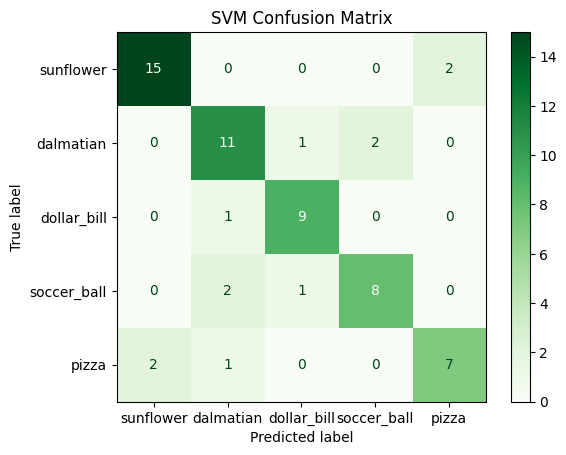

In [34]:
# Confusion Matrix

cm = confusion_matrix(y_test, svm_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=image_dataset.target_names
)

disp.plot(cmap="Greens")
plt.title("SVM Confusion Matrix")
plt.show()

Explaination: The SVM confusion matrix shows how well the SVM model classified the test images into the five categories. Most of the images were correctly classified, as shown by the higher values on the diagonal of the matrix. The model correctly classified 15 sunflower, 11 dalmatian, 9 dollar bill, 8 soccer ball, and 7 pizza images. A few images were misclassified, such as 2 sunflower images predicted as pizza, 2 dalmatian images predicted as soccer ball, and 2 pizza images predicted as sunflower. Compared to the Random Forest model, the SVM model made fewer classification errors and achieved a higher overall accuracy of 80.65%. This indicates that the SVM model was more effective at distinguishing between the different image categories in this dataset.

In [35]:
# Compare Random Forest and SVM

rf_accuracy = accuracy_score(y_test, y_pred)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("Random Forest Accuracy:", rf_accuracy)
print("SVM Accuracy:", svm_accuracy)

Random Forest Accuracy: 0.7419354838709677
SVM Accuracy: 0.8064516129032258


Explaination: The performance of the Random Forest and SVM models was compared using accuracy. The Random Forest model achieved an accuracy of 74.19%, while the SVM model achieved an accuracy of 80.65%. Since the SVM model had a higher accuracy, it performed better than the Random Forest model for this image classification dataset.